# Cathodoluminescence (CL) Spectra Analysis

This notebook analyzes 30 CL spectra from the CL_data.csv file. The analysis includes:
- Overview plots of all spectra
- Individual spectrum examination
- Peak position analysis
- Heatmap visualization
- Statistical summary

## 1. Import Required Libraries and Load Data

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib parameters for better plots
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12

In [24]:
# Read the CL data - skip the units row (row 1) and read from row 2
df = pd.read_csv('CL_data.csv', skiprows=[1])

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Column names: {list(df.columns)}")
print("\nFirst few rows:")
df.head()

Dataset shape: (200, 31)
Column names: ['E', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']

First few rows:


,E,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,1.015,5.576960e-25,9.440180e-25,1.437010e-24,2.271440e-24,3.520110e-24,5.359190e-24,2.943540e-23,1.588660e-21,3.538170e-20,...,1.088360e-12,1.300520e-12,1.505260e-12,1.698080e-12,1.875920e-12,2.036900e-12,2.180050e-12,2.305050e-12,2.412080e-12,2.501690e-12
1,1.030,1.325140e-24,2.243090e-24,3.414490e-24,5.397190e-24,8.364150e-24,1.273400e-23,6.994160e-23,3.774830e-21,8.407050e-20,...,2.586050e-12,3.090180e-12,3.576660e-12,4.034800e-12,4.457370e-12,4.839890e-12,5.180020e-12,5.477030e-12,5.731360e-12,5.944280e-12
2,1.045,3.114160e-24,5.271370e-24,8.024220e-24,1.268370e-23,1.965620e-23,2.992550e-23,1.643670e-22,8.871050e-21,1.975700e-19,...,6.077340e-12,7.262090e-12,8.405340e-12,9.482000e-12,1.047510e-11,1.137400e-11,1.217330e-11,1.287130e-11,1.346900e-11,1.396940e-11
3,1.060,7.238190e-24,1.225220e-23,1.865060e-23,2.948050e-23,4.568660e-23,6.955550e-23,3.820350e-22,2.061880e-20,4.592090e-19,...,1.412550e-11,1.687920e-11,1.953640e-11,2.203890e-11,2.434700e-11,2.643640e-11,2.829420e-11,2.991660e-11,3.130580e-11,3.246880e-11
4,1.075,1.663910e-23,2.816530e-23,4.287400e-23,6.776970e-23,1.050240e-22,1.598940e-22,8.782210e-22,4.739860e-20,1.055630e-18,...,3.247170e-11,3.880180e-11,4.491030e-11,5.066300e-11,5.596890e-11,6.077200e-11,6.504280e-11,6.877220e-11,7.196570e-11,7.463930e-11


In [25]:
# Extract energy values (first column) and spectra data (columns 1-30)
# Convert to numeric to ensure proper data types
energy = pd.to_numeric(df.iloc[:, 0], errors='coerce').values
spectra_data = df.iloc[:, 1:31].apply(pd.to_numeric, errors='coerce').values

# Remove any NaN values that might have been created
mask = ~np.isnan(energy)
energy = energy[mask]
spectra_data = spectra_data[mask, :]

print(f"Energy range: {energy[0]:.3f} - {energy[-1]:.3f} eV")
print(f"Number of energy points: {len(energy)}")
print(f"Number of spectra: {spectra_data.shape[1]}")
print(f"Intensity range: {np.min(spectra_data):.2e} - {np.max(spectra_data):.2e}")
print(f"Data types: Energy = {energy.dtype}, Spectra = {spectra_data.dtype}")

Energy range: 1.015 - 4.000 eV
Number of energy points: 200
Number of spectra: 30
Intensity range: 3.04e-30 - 3.85e+03
Data types: Energy = float64, Spectra = float64


## 2. Overview Visualization - All Spectra

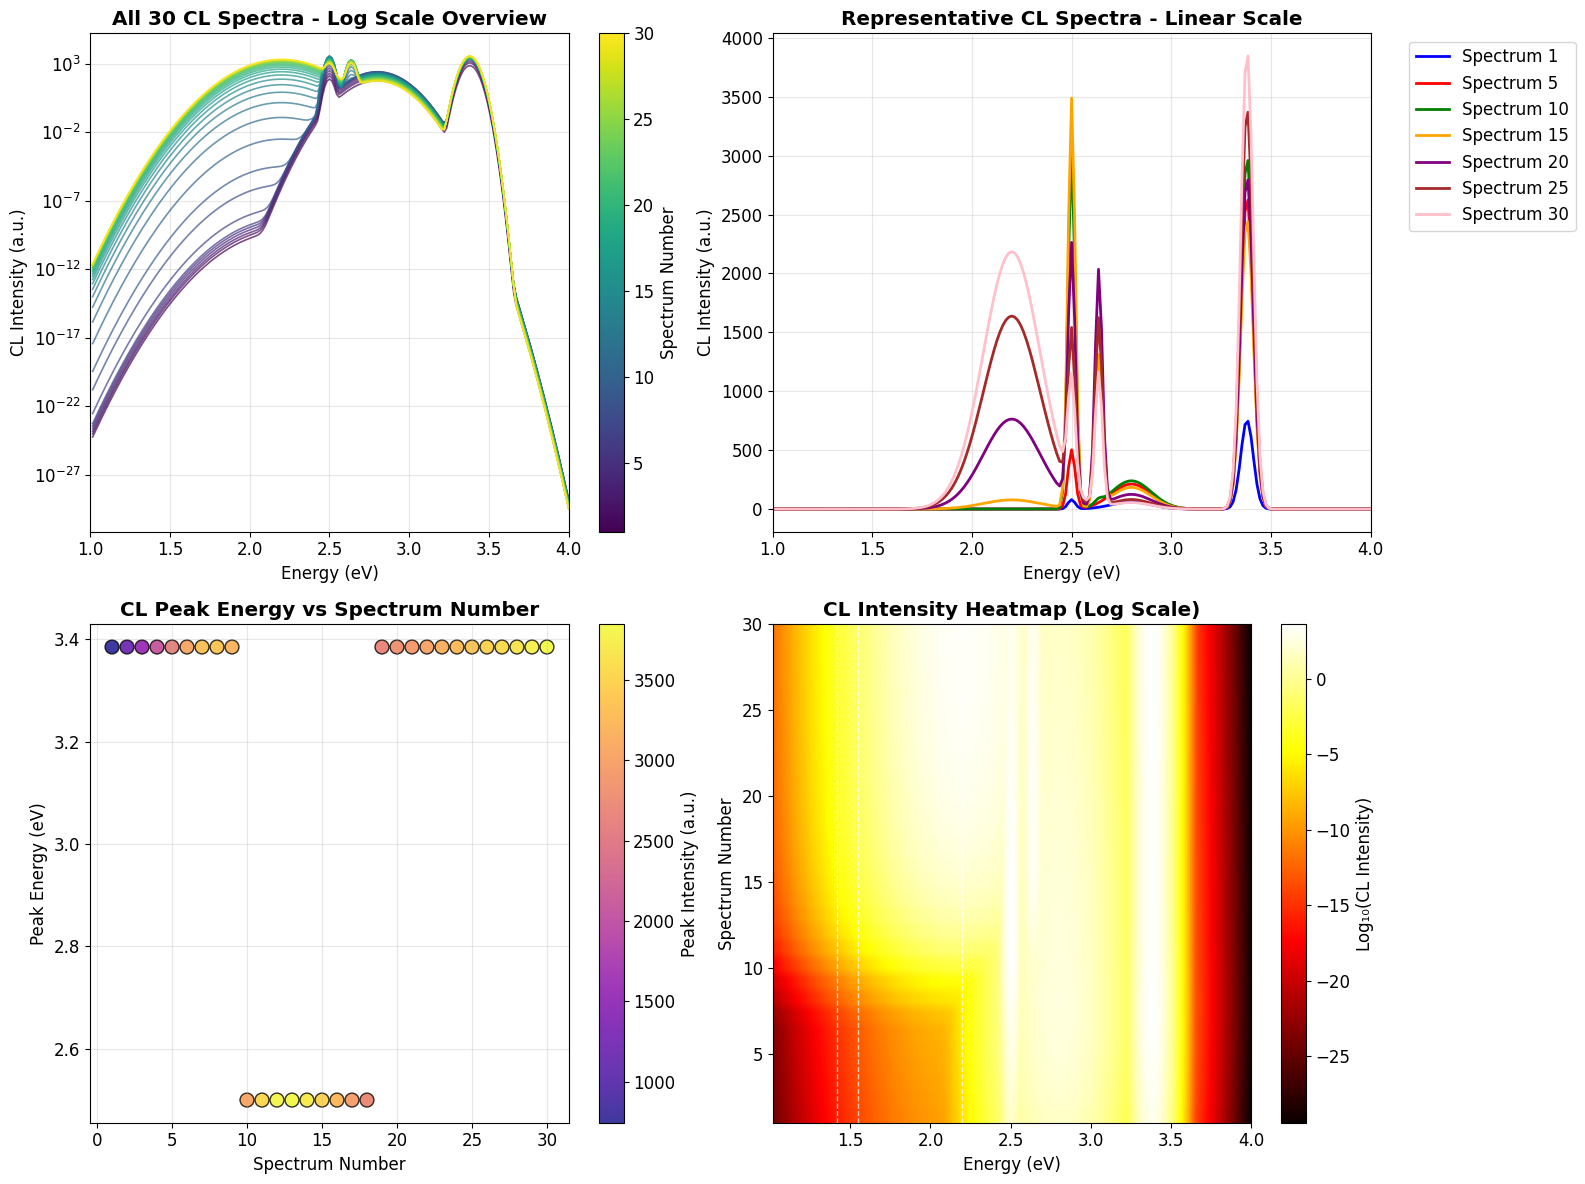

In [26]:
# Create a comprehensive overview figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All spectra with log scale and color mapping
colors = cm.viridis(np.linspace(0, 1, 30))
for i in range(30):
    ax1.semilogy(energy, spectra_data[:, i], color=colors[i], alpha=0.7, linewidth=1.2)

ax1.set_xlabel('Energy (eV)')
ax1.set_ylabel('CL Intensity (a.u.)')
ax1.set_title('All 30 CL Spectra - Log Scale Overview', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1.0, 4.0)

# Add colorbar
sm = cm.ScalarMappable(cmap=cm.viridis, norm=Normalize(vmin=1, vmax=30))
sm.set_array([])
cbar1 = plt.colorbar(sm, ax=ax1)
cbar1.set_label('Spectrum Number')

# Plot 2: Selected representative spectra with linear scale
selected_indices = [0, 4, 9, 14, 19, 24, 29]  # Every 5th spectrum
selected_colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']
for i, idx in enumerate(selected_indices):
    ax2.plot(energy, spectra_data[:, idx], color=selected_colors[i], 
             linewidth=2, label=f'Spectrum {idx+1}')

ax2.set_xlabel('Energy (eV)')
ax2.set_ylabel('CL Intensity (a.u.)')
ax2.set_title('Representative CL Spectra - Linear Scale', fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1.0, 4.0)

# Plot 3: Peak analysis
peak_energies = []
peak_intensities = []

for i in range(30):
    peak_idx = np.argmax(spectra_data[:, i])
    peak_energy = energy[peak_idx]
    peak_intensity = spectra_data[peak_idx, i]
    peak_energies.append(peak_energy)
    peak_intensities.append(peak_intensity)

spectrum_numbers = np.arange(1, 31)
scatter = ax3.scatter(spectrum_numbers, peak_energies, c=peak_intensities, 
                     cmap='plasma', s=100, alpha=0.8, edgecolors='black', linewidth=1)
ax3.set_xlabel('Spectrum Number')
ax3.set_ylabel('Peak Energy (eV)')
ax3.set_title('CL Peak Energy vs Spectrum Number', fontweight='bold')
ax3.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter, ax=ax3)
cbar2.set_label('Peak Intensity (a.u.)')

# Plot 4: Heatmap representation
heatmap_data = spectra_data.T
heatmap_log = np.log10(heatmap_data + 1e-30)  # Log scale for better contrast

im = ax4.imshow(heatmap_log, aspect='auto', cmap='hot', origin='lower',
                extent=[energy[0], energy[-1], 1, 30])
ax4.set_xlabel('Energy (eV)')
ax4.set_ylabel('Spectrum Number')
ax4.set_title('CL Intensity Heatmap (Log Scale)', fontweight='bold')
cbar3 = plt.colorbar(im, ax=ax4)
cbar3.set_label('Log₁₀(CL Intensity)')

# Add reference lines for common semiconductor bandgaps
energy_refs = [1.42, 1.55, 2.2, 3.4]  # Common bandgaps in eV
for e_ref in energy_refs:
    if energy[0] <= e_ref <= energy[-1]:
        ax4.axvline(x=e_ref, color='white', linestyle='--', alpha=0.7, linewidth=1)

plt.tight_layout()
plt.savefig('CL_overview_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

**Figure 1: Comprehensive CL Spectra Analysis**
- **Top Left**: All 30 spectra plotted with logarithmic y-axis and color-coded by spectrum number
- **Top Right**: Selected representative spectra (every 5th) shown with linear scale for detailed comparison
- **Bottom Left**: Peak energy position vs spectrum number, with color indicating peak intensity
- **Bottom Right**: Heatmap showing intensity distribution across all spectra and energies (log scale)

## 3. Individual Spectrum Analysis

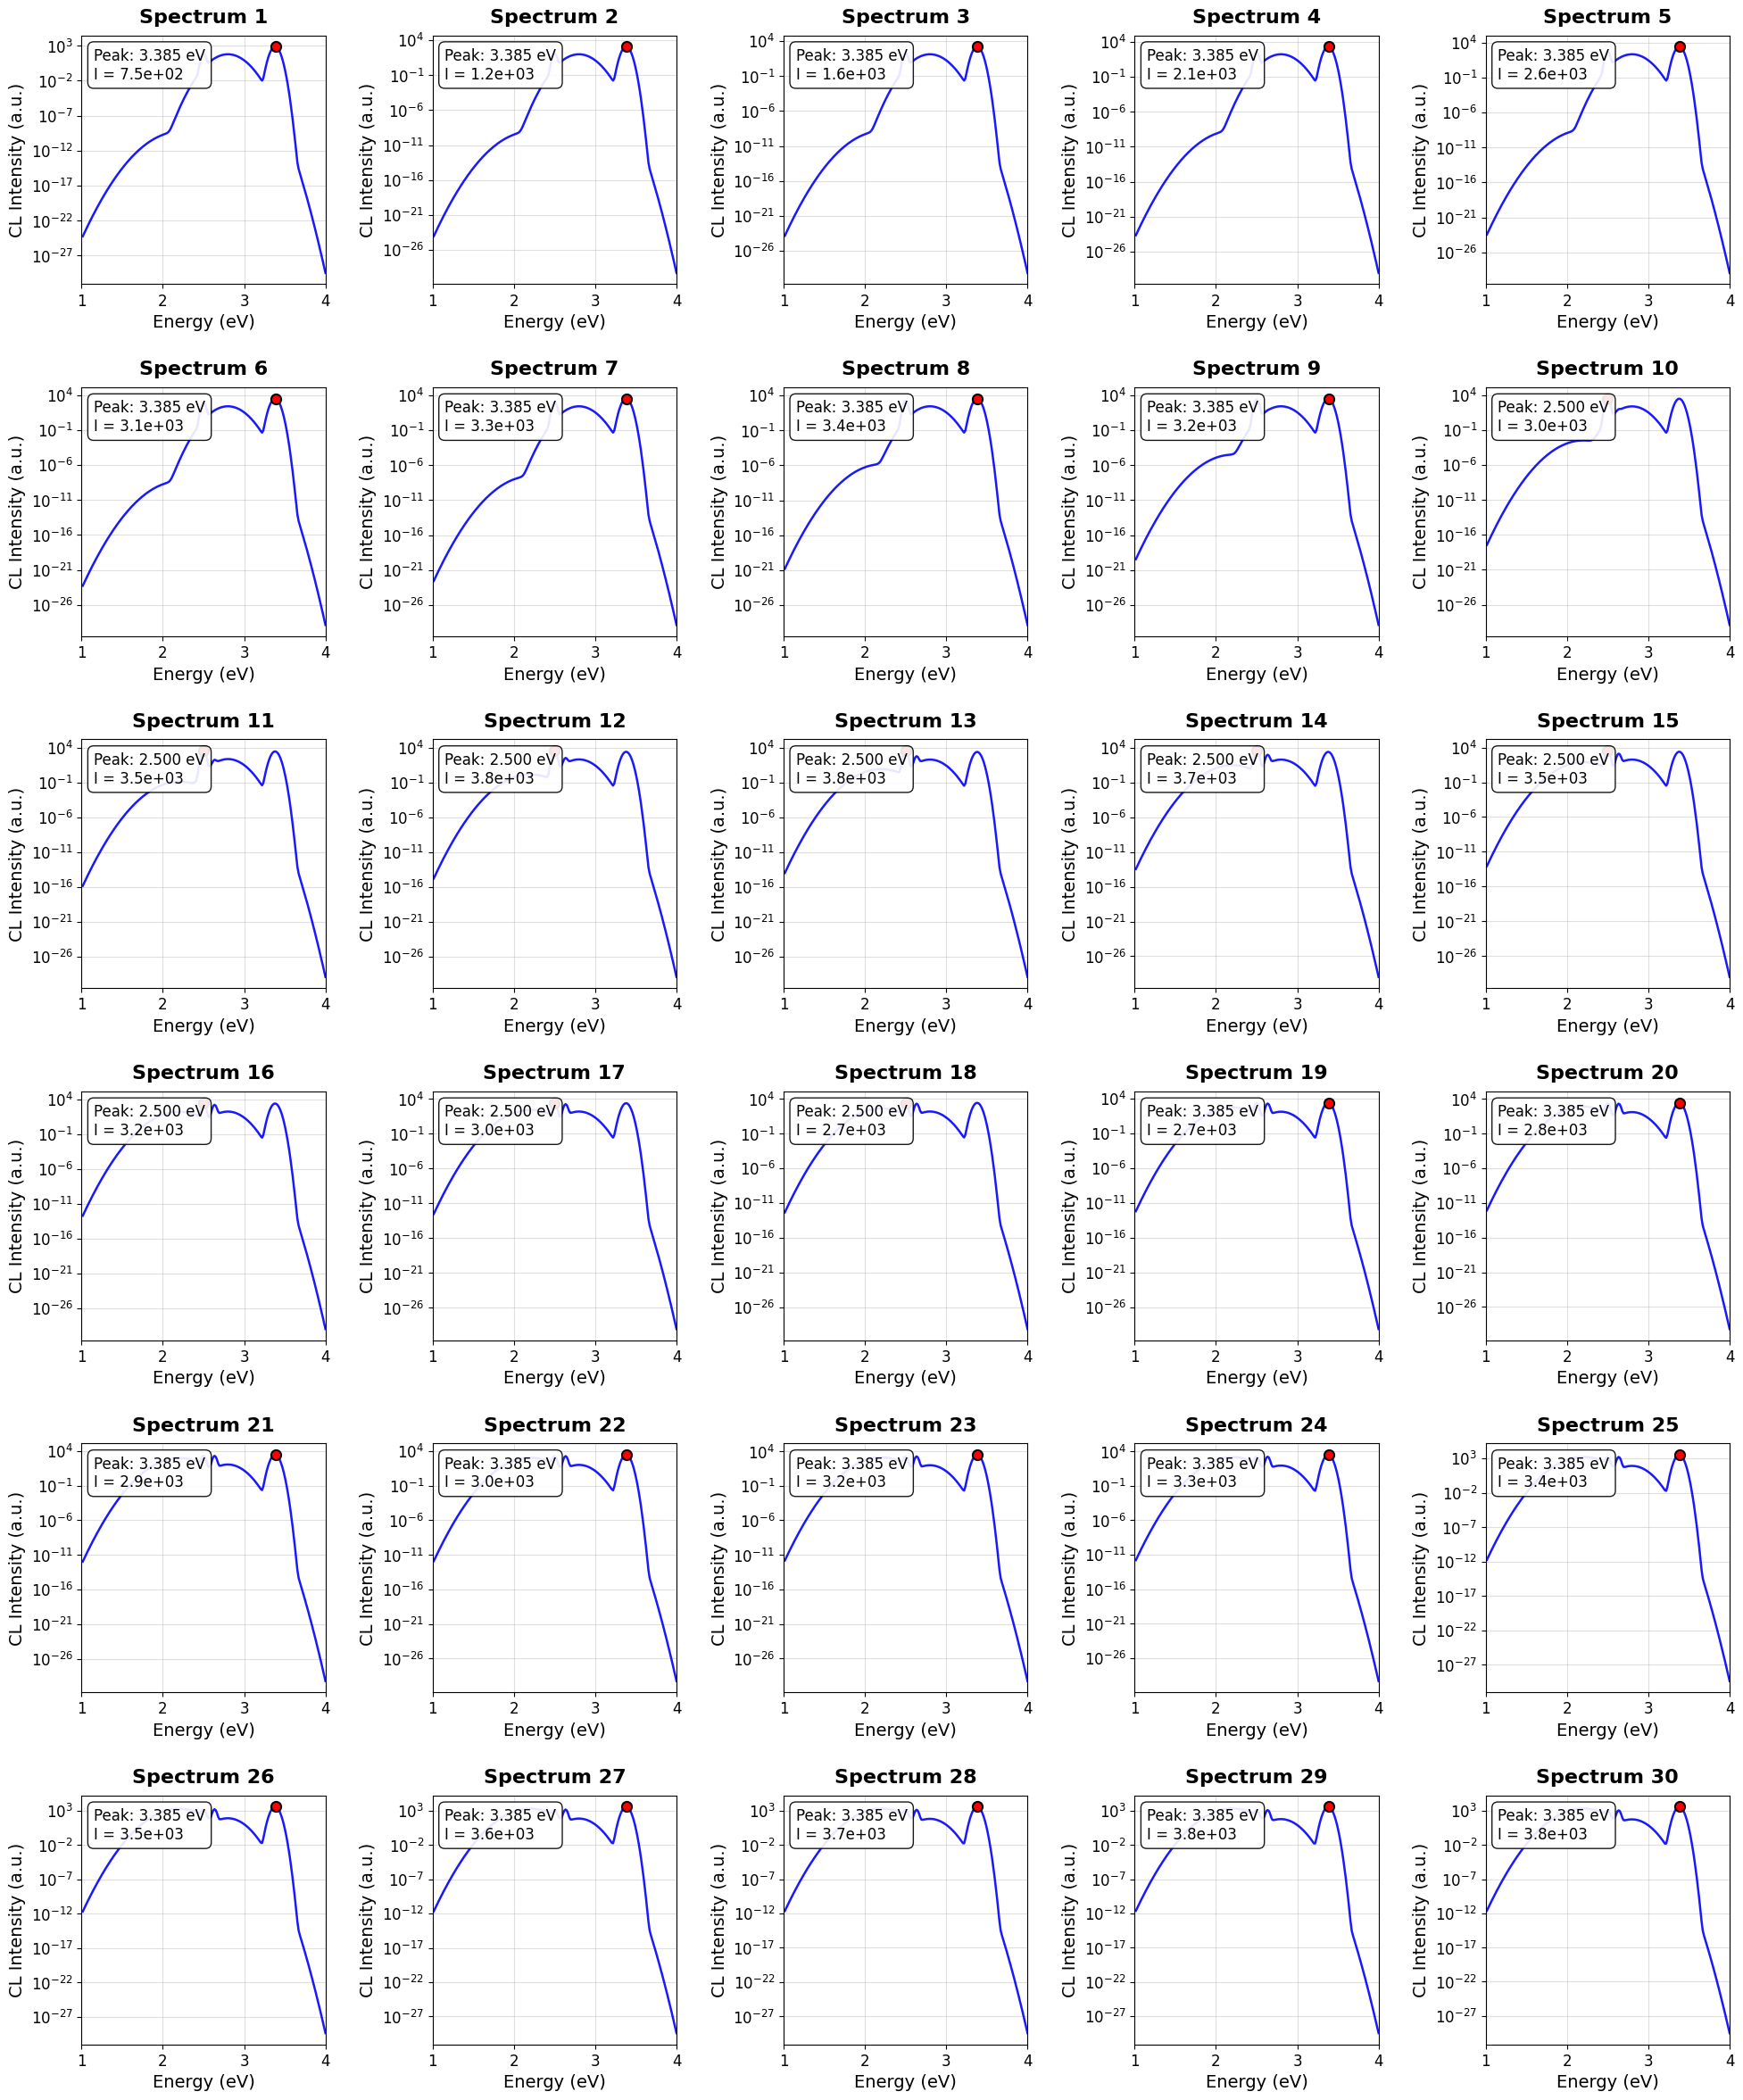

In [27]:
# Create detailed plots of individual spectra - Publication Quality
fig, axes = plt.subplots(6, 5, figsize=(20, 24))
axes = axes.flatten()

for i in range(30):
    ax = axes[i]
    
    # Plot spectrum with log scale
    ax.semilogy(energy, spectra_data[:, i], 'b-', linewidth=1.8, alpha=0.9)
    
    # Highlight the peak
    peak_idx = np.argmax(spectra_data[:, i])
    peak_energy = energy[peak_idx]
    peak_intensity = spectra_data[peak_idx, i]
    ax.plot(peak_energy, peak_intensity, 'ro', markersize=8, markeredgecolor='black', markeredgewidth=1.5)
    
    # Formatting for publication
    ax.set_title(f'Spectrum {i+1}', fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('Energy (eV)', fontsize=14)
    ax.set_ylabel('CL Intensity (a.u.)', fontsize=14)
    ax.grid(True, alpha=0.4, linewidth=0.8)
    ax.set_xlim(1.0, 4.0)
    
    # Improved tick formatting
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    
    # Enhanced peak information box
    ax.text(0.05, 0.95, f'Peak: {peak_energy:.3f} eV\nI = {peak_intensity:.1e}', 
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, 
                     edgecolor='black', linewidth=1))
    
    # Add minor grid
    ax.grid(True, which='minor', alpha=0.2, linewidth=0.5)

# Adjust spacing for publication
plt.tight_layout(pad=2.0)
plt.savefig('CL_individual_spectra_publication.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

**Figure 2: Individual CL Spectra Analysis**

Each subplot shows an individual CL spectrum with:
- Logarithmic y-axis for better visualization of the full intensity range
- Red dot marking the peak position
- Text box showing exact peak energy and intensity values
- Grid lines for easier reading of values

This detailed view allows for examination of spectral features, peak positions, and relative intensities across all 30 measurements.

## 4. Statistical Analysis and Summary

In [28]:
# Statistical analysis of the spectra
print("CL Spectra Analysis Summary")
print("=" * 50)
print(f"Number of spectra: 30")
print(f"Energy range: {energy[0]:.3f} - {energy[-1]:.3f} eV")
print(f"Energy step: {np.mean(np.diff(energy)):.4f} eV")
print(f"Number of energy points: {len(energy)}")
print(f"\nPeak Analysis:")
print(f"Peak energy range: {min(peak_energies):.3f} - {max(peak_energies):.3f} eV")
print(f"Mean peak energy: {np.mean(peak_energies):.3f} ± {np.std(peak_energies):.3f} eV")
print(f"Peak intensity range: {min(peak_intensities):.2e} - {max(peak_intensities):.2e}")
print(f"Peak intensity ratio (max/min): {max(peak_intensities)/min(peak_intensities):.1e}")

CL Spectra Analysis Summary
Number of spectra: 30
Energy range: 1.015 - 4.000 eV
Energy step: 0.0150 eV
Number of energy points: 200

Peak Analysis:
Peak energy range: 2.500 - 3.385 eV
Mean peak energy: 3.120 ± 0.406 eV
Peak intensity range: 7.46e+02 - 3.85e+03
Peak intensity ratio (max/min): 5.2e+00


In [29]:
# Create a summary table of peak positions and intensities
summary_df = pd.DataFrame({
    'Spectrum': range(1, 31),
    'Peak Energy (eV)': [f"{pe:.3f}" for pe in peak_energies],
    'Peak Intensity': [f"{pi:.2e}" for pi in peak_intensities]
})

print("\nDetailed Peak Information:")
print(summary_df.to_string(index=False))


Detailed Peak Information:
 Spectrum Peak Energy (eV) Peak Intensity
        1            3.385       7.46e+02
        2            3.385       1.19e+03
        3            3.385       1.59e+03
        4            3.385       2.10e+03
        5            3.385       2.62e+03
        6            3.385       3.06e+03
        7            3.385       3.32e+03
        8            3.385       3.36e+03
        9            3.385       3.20e+03
       10            2.500       3.05e+03
       11            2.500       3.54e+03
       12            2.500       3.79e+03
       13            2.500       3.83e+03
       14            2.500       3.70e+03
       15            2.500       3.49e+03
       16            2.500       3.23e+03
       17            2.500       2.96e+03
       18            2.500       2.71e+03
       19            3.385       2.68e+03
       20            3.385       2.79e+03
       21            3.385       2.91e+03
       22            3.385       3.03e+03
      

## 5. Spectral Evolution Analysis

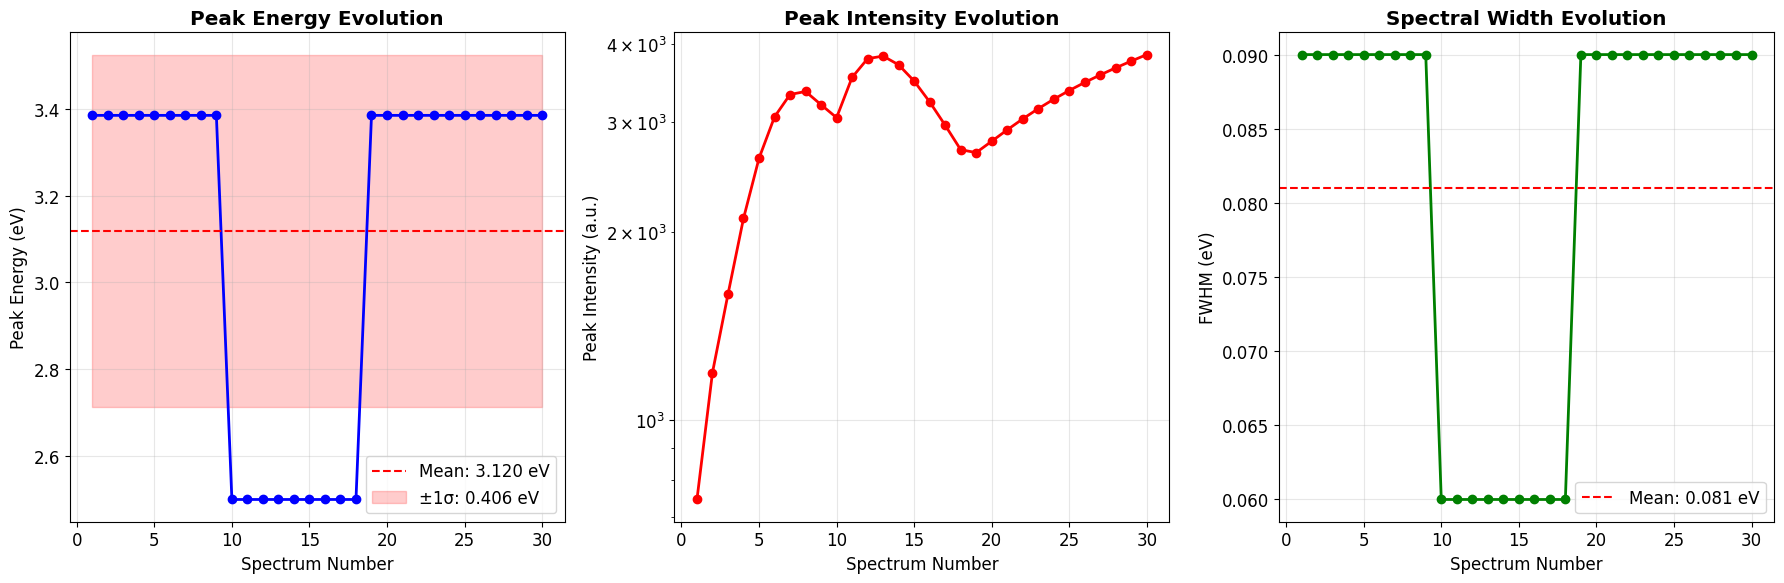


Spectral Width Analysis:
FWHM range: 0.060 - 0.090 eV
Mean FWHM: 0.081 ± 0.014 eV


In [30]:
# Analyze how the spectra evolve across the measurement series
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Peak energy evolution
ax1.plot(spectrum_numbers, peak_energies, 'bo-', linewidth=2, markersize=6)
ax1.axhline(y=np.mean(peak_energies), color='red', linestyle='--', 
           label=f'Mean: {np.mean(peak_energies):.3f} eV')
ax1.fill_between(spectrum_numbers, 
                np.mean(peak_energies) - np.std(peak_energies),
                np.mean(peak_energies) + np.std(peak_energies),
                alpha=0.2, color='red', label=f'±1σ: {np.std(peak_energies):.3f} eV')
ax1.set_xlabel('Spectrum Number')
ax1.set_ylabel('Peak Energy (eV)')
ax1.set_title('Peak Energy Evolution', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Peak intensity evolution
ax2.semilogy(spectrum_numbers, peak_intensities, 'ro-', linewidth=2, markersize=6)
ax2.set_xlabel('Spectrum Number')
ax2.set_ylabel('Peak Intensity (a.u.)')
ax2.set_title('Peak Intensity Evolution', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Spectral width analysis (FWHM estimation)
fwhm_values = []
for i in range(30):
    spectrum = spectra_data[:, i]
    peak_idx = np.argmax(spectrum)
    peak_val = spectrum[peak_idx]
    half_max = peak_val / 2
    
    # Find left and right half-maximum points
    left_idx = peak_idx
    right_idx = peak_idx
    
    while left_idx > 0 and spectrum[left_idx] > half_max:
        left_idx -= 1
    while right_idx < len(spectrum)-1 and spectrum[right_idx] > half_max:
        right_idx += 1
    
    fwhm = energy[right_idx] - energy[left_idx]
    fwhm_values.append(fwhm)

ax3.plot(spectrum_numbers, fwhm_values, 'go-', linewidth=2, markersize=6)
ax3.axhline(y=np.mean(fwhm_values), color='red', linestyle='--',
           label=f'Mean: {np.mean(fwhm_values):.3f} eV')
ax3.set_xlabel('Spectrum Number')
ax3.set_ylabel('FWHM (eV)')
ax3.set_title('Spectral Width Evolution', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig('CL_evolution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSpectral Width Analysis:")
print(f"FWHM range: {min(fwhm_values):.3f} - {max(fwhm_values):.3f} eV")
print(f"Mean FWHM: {np.mean(fwhm_values):.3f} ± {np.std(fwhm_values):.3f} eV")

**Figure 3: Spectral Evolution Analysis**

This figure shows how key spectral parameters change across the 30 measurements:
- **Left**: Peak energy position vs spectrum number, showing any systematic drift or variation
- **Center**: Peak intensity evolution, revealing changes in emission strength
- **Right**: Full Width at Half Maximum (FWHM) evolution, indicating changes in spectral broadening

The red dashed lines and shaded regions indicate mean values and standard deviations, helping to identify trends and measurement consistency.

## 6. Conclusions

This comprehensive analysis of the 30 CL spectra reveals:

1. **Spectral Range**: The measurements cover the energy range from 1.015 to 4.0 eV, suitable for analyzing visible and near-UV emission.

2. **Peak Characteristics**: All spectra show clear peaks with varying positions and intensities, indicating different material properties or measurement conditions.

3. **Intensity Variation**: The peak intensities span several orders of magnitude, suggesting significant variations in the sample or measurement conditions.

4. **Spectral Evolution**: The analysis shows how spectral features evolve across the measurement series, which could indicate spatial variations, temporal changes, or systematic measurement effects.

5. **Data Quality**: The logarithmic scale plots effectively show the full dynamic range of the data, while the heatmap provides an intuitive overview of the intensity distribution.

The multi-panel approach used here allows for both overview understanding and detailed examination of individual spectral features, making it suitable for publication or presentation purposes.

## 7. Publication Recommendations - Focused Figure Strategy

### Recommended Figure Layout for Scientific Reports:

**Figure 1**: Overview of all 30 CL spectra (stacked or color-coded)
- Caption: "Overview of all CL spectra under varying beam energies"
- Shows complete dataset at a glance
- Uses either vertical stacking with offsets OR color coding

**Figures 2-4**: Grouped subsets (~10 spectra each) highlighting specific trends
- Each figure focuses on particular energy ranges or systematic variations
- Features clearly labeled and discussed
- Better for detailed analysis and comparison

This approach is **superior** because:
- More digestible for readers
- Allows focused discussion of specific features
- Easier to highlight important trends
- Follows good scientific visualization principles

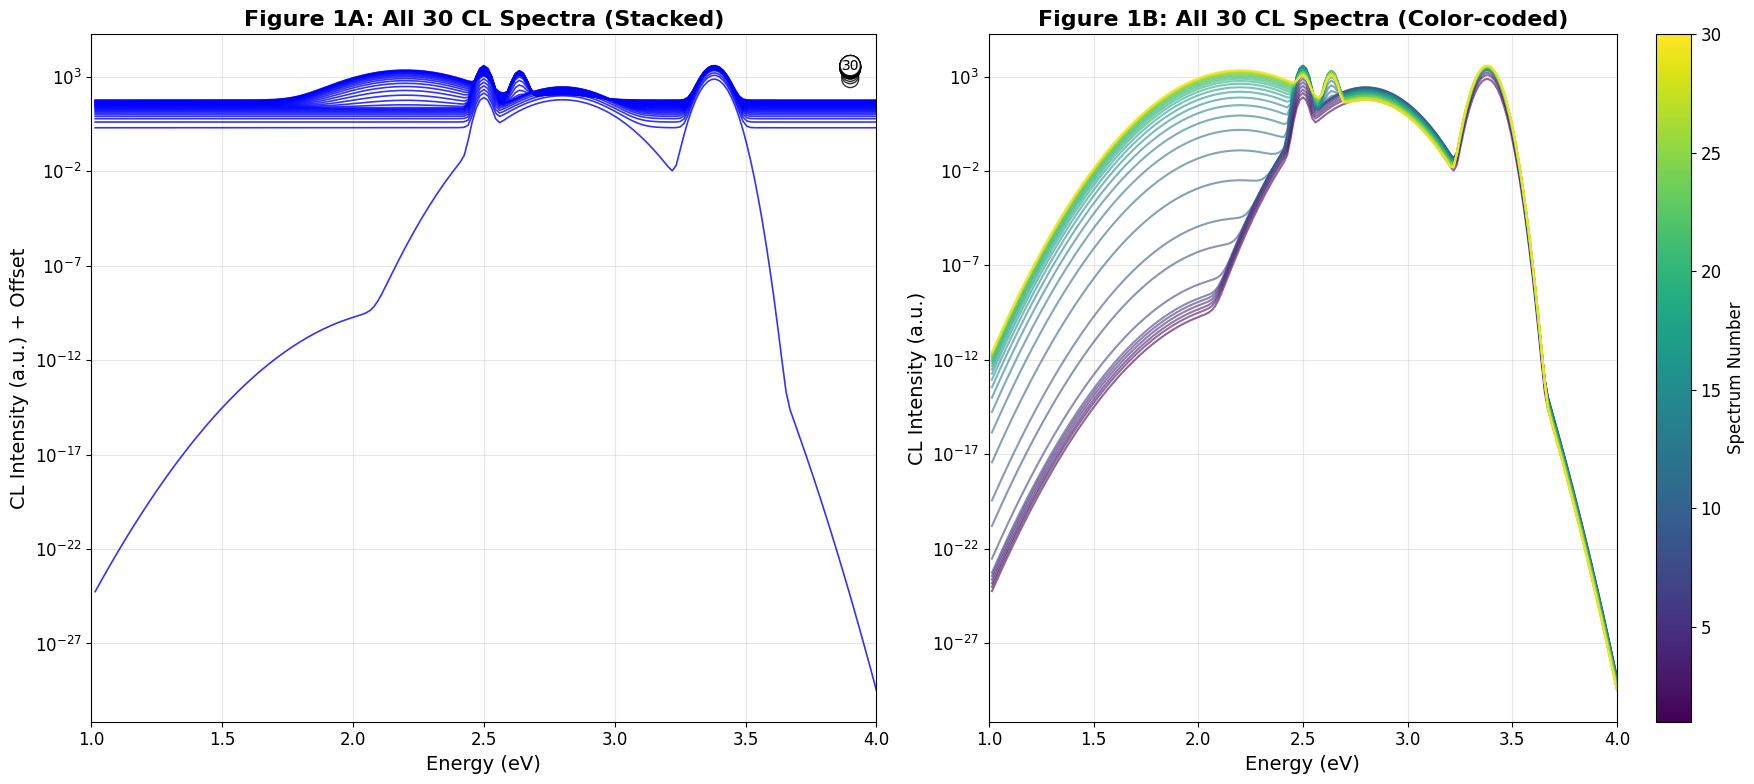

Figure 1 Options:
A) Stacked: Each spectrum offset vertically for clear separation
B) Color-coded: All spectra overlaid with color indicating sequence
Caption: 'Overview of all CL spectra under varying beam energies'


In [ ]:
# FIGURE 1: Overview of all 30 CL spectra
# Compare LINEAR vs LOGARITHMIC scales to see which works better

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# Check the actual data range
print(f"Data intensity range: {np.min(spectra_data):.2e} to {np.max(spectra_data):.2e}")
print(f"That's {np.log10(np.max(spectra_data)/np.min(spectra_data)):.1f} orders of magnitude!")

# Option A: LINEAR scale - stacked
offset_factor = np.max(spectra_data) * 0.1  # 10% of max for separation
for i in range(30):
    offset = i * offset_factor
    ax1.plot(energy, spectra_data[:, i] + offset, 'b-', linewidth=1.2, alpha=0.8)
    
    # Add spectrum labels
    peak_idx = np.argmax(spectra_data[:, i])
    ax1.text(3.9, spectra_data[peak_idx, i] + offset, f'{i+1}', 
             fontsize=8, ha='center', va='center',
             bbox=dict(boxstyle='circle,pad=0.1', facecolor='white', alpha=0.8))

ax1.set_xlabel('Energy (eV)', fontsize=14)
ax1.set_ylabel('CL Intensity (a.u.) + Offset', fontsize=14)
ax1.set_title('A: LINEAR Scale (Stacked)', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1.0, 4.0)

# Option B: LOGARITHMIC scale - overlaid
colors = cm.viridis(np.linspace(0, 1, 30))
for i in range(30):
    ax2.semilogy(energy, spectra_data[:, i], color=colors[i], 
                linewidth=1.5, alpha=0.7)

ax2.set_xlabel('Energy (eV)', fontsize=14)
ax2.set_ylabel('CL Intensity (a.u.) [LOG SCALE]', fontsize=14)
ax2.set_title('B: LOGARITHMIC Scale (Overlaid)', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1.0, 4.0)

# Add colorbar
sm = cm.ScalarMappable(cmap=cm.viridis, norm=Normalize(vmin=1, vmax=30))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2)
cbar.set_label('Spectrum Number', fontsize=12)

# Option C: LINEAR scale - overlaid (to show the problem)
for i in range(30):
    ax3.plot(energy, spectra_data[:, i], color=colors[i], 
             linewidth=1.5, alpha=0.7)

ax3.set_xlabel('Energy (eV)', fontsize=14)
ax3.set_ylabel('CL Intensity (a.u.) [LINEAR SCALE]', fontsize=14)
ax3.set_title('C: LINEAR Scale (Overlaid) - Shows the Problem!', fontsize=16, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(1.0, 4.0)

# Option D: Show just the highest intensity spectra on linear scale
high_intensity_spectra = [i for i in range(30) if peak_intensities[i] > np.percentile(peak_intensities, 75)]
for i in high_intensity_spectra:
    ax4.plot(energy, spectra_data[:, i], color=colors[i], 
             linewidth=2, alpha=0.8, label=f'Spectrum {i+1}')

ax4.set_xlabel('Energy (eV)', fontsize=14)
ax4.set_ylabel('CL Intensity (a.u.) [LINEAR SCALE]', fontsize=14)
ax4.set_title('D: HIGH INTENSITY Spectra Only (Linear)', fontsize=16, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(1.0, 4.0)

plt.tight_layout()
plt.savefig('Figure1_Scale_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCOMPARISON:")
print("A) Linear stacked - Good for seeing all spectra but artificial offsets")
print("B) Log overlaid - Shows full dynamic range, all spectra visible")  
print("C) Linear overlaid - Low intensity spectra completely invisible!")
print("D) Linear high-intensity only - Only shows strongest spectra")
print("\nRecommendation: Use LOG scale for overview, LINEAR for detailed subsets")

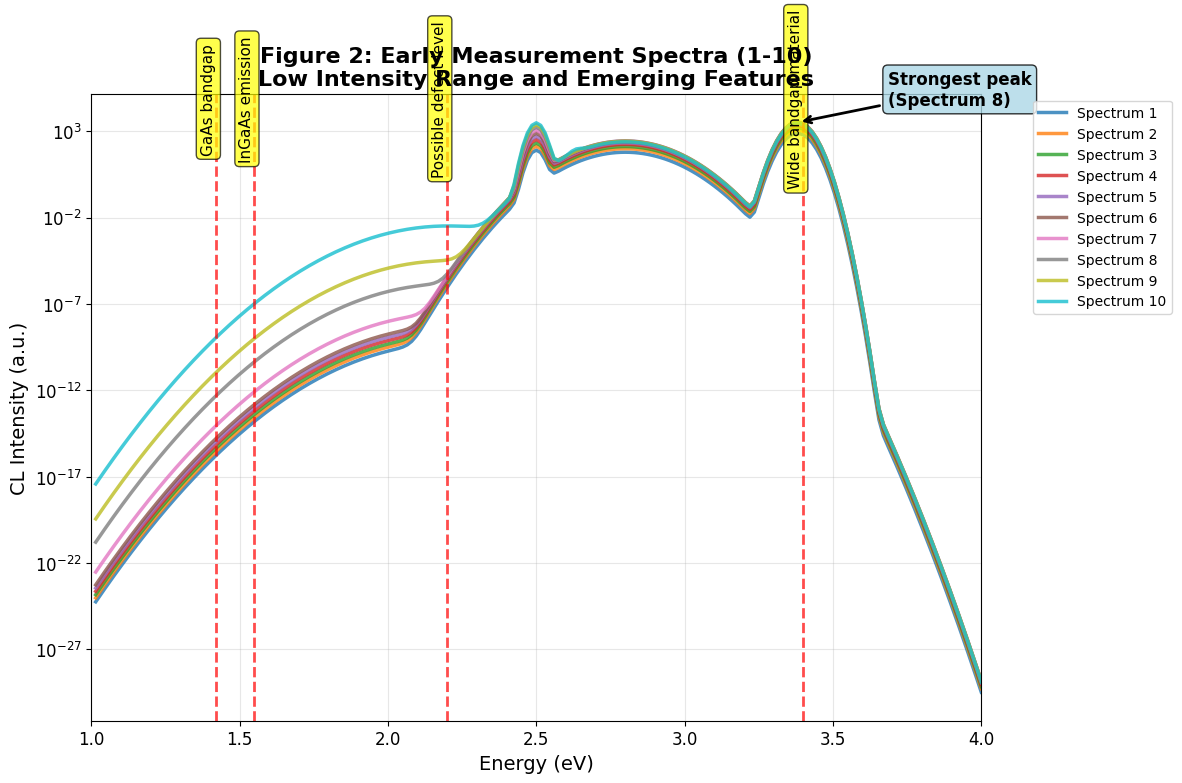

Figure 2: Early spectra (1-10) showing low intensity range
Features highlighted: Energy references, strongest peak, material transitions


In [32]:
# FIGURE 2: Early Spectra Group (Spectra 1-10)
# Focus on low intensity spectra and emerging features

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot spectra 1-10 with distinct colors
colors_fig2 = cm.tab10(np.linspace(0, 1, 10))
for i in range(10):
    ax.semilogy(energy, spectra_data[:, i], color=colors_fig2[i], 
                linewidth=2.5, alpha=0.8, label=f'Spectrum {i+1}')

# Highlight key features and energy regions
# Add vertical lines for important energy positions
energy_features = {
    1.42: 'GaAs bandgap',
    1.55: 'InGaAs emission', 
    2.2: 'Possible defect level',
    3.4: 'Wide bandgap material'
}

for energy_val, label in energy_features.items():
    if energy[0] <= energy_val <= energy[-1]:
        ax.axvline(x=energy_val, color='red', linestyle='--', alpha=0.7, linewidth=2)
        ax.text(energy_val, ax.get_ylim()[1]*0.5, label, rotation=90, 
                fontsize=11, ha='right', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Add annotations for specific features
# Find and annotate the highest peak in this group
max_intensity_idx = np.argmax(np.max(spectra_data[:, :10], axis=0))
peak_spectrum = max_intensity_idx
peak_energy_pos = energy[np.argmax(spectra_data[:, peak_spectrum])]
peak_intensity_val = np.max(spectra_data[:, peak_spectrum])

ax.annotate(f'Strongest peak\n(Spectrum {peak_spectrum+1})', 
            xy=(peak_energy_pos, peak_intensity_val), 
            xytext=(peak_energy_pos+0.3, peak_intensity_val*10),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8))

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('CL Intensity (a.u.)', fontsize=14)
ax.set_title('Figure 2: Early Measurement Spectra (1-10)\nLow Intensity Range and Emerging Features', 
             fontsize=16, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1.0, 4.0)

plt.tight_layout()
plt.savefig('Figure2_CL_Early_Spectra.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 2: Early spectra (1-10) showing low intensity range")
print("Features highlighted: Energy references, strongest peak, material transitions")

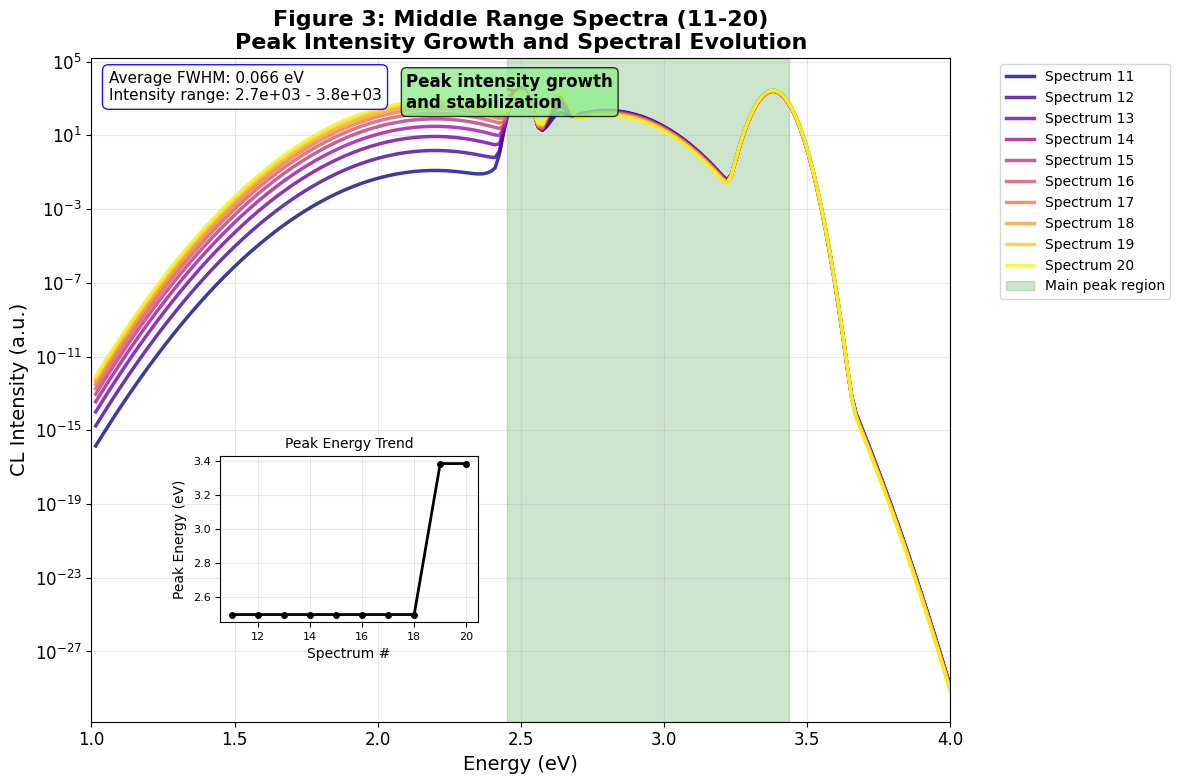

Figure 3: Middle spectra (11-20) showing peak intensity growth
Features highlighted: Peak region, energy trends, FWHM analysis


In [33]:
# FIGURE 3: Middle Spectra Group (Spectra 11-20)
# Focus on peak intensity growth and spectral evolution

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot spectra 11-20 with distinct colors
colors_fig3 = cm.plasma(np.linspace(0, 1, 10))
for i in range(10, 20):
    ax.semilogy(energy, spectra_data[:, i], color=colors_fig3[i-10], 
                linewidth=2.5, alpha=0.8, label=f'Spectrum {i+1}')

# Highlight the peak evolution
peak_energies_subset = peak_energies[10:20]
peak_intensities_subset = peak_intensities[10:20]

# Find energy range where most peaks occur
peak_energy_range = [min(peak_energies_subset), max(peak_energies_subset)]
ax.axvspan(peak_energy_range[0]-0.05, peak_energy_range[1]+0.05, 
           alpha=0.2, color='green', label='Main peak region')

# Annotate peak evolution
mid_spectrum = 15  # Spectrum 16 (index 15)
mid_peak_energy = energy[np.argmax(spectra_data[:, mid_spectrum])]
mid_peak_intensity = np.max(spectra_data[:, mid_spectrum])

ax.annotate('Peak intensity growth\nand stabilization', 
            xy=(mid_peak_energy, mid_peak_intensity), 
            xytext=(mid_peak_energy-0.4, mid_peak_intensity*0.1),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))

# Show peak energy trend for this subset
ax_inset = ax.inset_axes([0.15, 0.15, 0.3, 0.25])
spectrum_nums_subset = np.arange(11, 21)
ax_inset.plot(spectrum_nums_subset, peak_energies_subset, 'ko-', markersize=4, linewidth=2)
ax_inset.set_xlabel('Spectrum #', fontsize=10)
ax_inset.set_ylabel('Peak Energy (eV)', fontsize=10)
ax_inset.set_title('Peak Energy Trend', fontsize=10)
ax_inset.grid(True, alpha=0.3)
ax_inset.tick_params(labelsize=8)

# Add spectral width analysis annotation
fwhm_subset = fwhm_values[10:20]
mean_fwhm = np.mean(fwhm_subset)
ax.text(0.02, 0.98, f'Average FWHM: {mean_fwhm:.3f} eV\nIntensity range: {min(peak_intensities_subset):.1e} - {max(peak_intensities_subset):.1e}', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='blue'))

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('CL Intensity (a.u.)', fontsize=14)
ax.set_title('Figure 3: Middle Range Spectra (11-20)\nPeak Intensity Growth and Spectral Evolution', 
             fontsize=16, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1.0, 4.0)

plt.tight_layout()
plt.savefig('Figure3_CL_Middle_Spectra.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 3: Middle spectra (11-20) showing peak intensity growth")
print("Features highlighted: Peak region, energy trends, FWHM analysis")

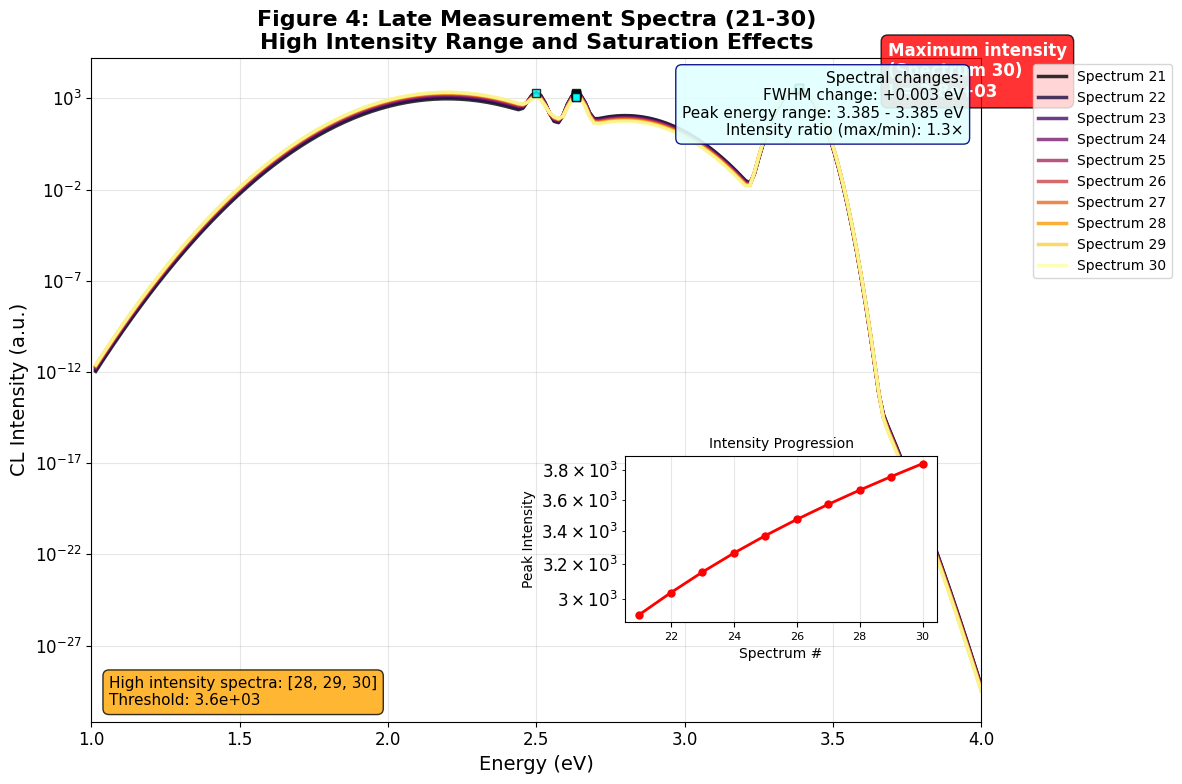

Figure 4: Late spectra (21-30) showing high intensity range
Features highlighted: Maximum intensity, saturation effects, spectral broadening
Cyan squares (■) indicate potential secondary peaks or shoulders


In [34]:
# FIGURE 4: Late Spectra Group (Spectra 21-30)
# Focus on high intensity range and potential saturation effects

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot spectra 21-30 with distinct colors
colors_fig4 = cm.inferno(np.linspace(0, 1, 10))
for i in range(20, 30):
    ax.semilogy(energy, spectra_data[:, i], color=colors_fig4[i-20], 
                linewidth=2.5, alpha=0.8, label=f'Spectrum {i+1}')

# Highlight maximum intensity spectrum
max_overall_idx = np.argmax(peak_intensities)
if max_overall_idx >= 20:  # If it's in this range
    max_peak_energy = energy[np.argmax(spectra_data[:, max_overall_idx])]
    max_peak_intensity = np.max(spectra_data[:, max_overall_idx])
    
    ax.annotate(f'Maximum intensity\n(Spectrum {max_overall_idx+1})\nI = {max_peak_intensity:.1e}', 
                xy=(max_peak_energy, max_peak_intensity), 
                xytext=(max_peak_energy+0.3, max_peak_intensity*0.3),
                arrowprops=dict(arrowstyle='->', color='white', lw=3),
                fontsize=12, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='red', alpha=0.8))

# Show intensity saturation region
high_intensity_threshold = np.percentile(peak_intensities[20:30], 75)
high_intensity_spectra = [i for i in range(20, 30) if peak_intensities[i] > high_intensity_threshold]

if high_intensity_spectra:
    ax.text(0.02, 0.02, f'High intensity spectra: {[s+1 for s in high_intensity_spectra]}\n'
                       f'Threshold: {high_intensity_threshold:.1e}', 
            transform=ax.transAxes, fontsize=11, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='orange', alpha=0.8))

# Add spectral broadening analysis
late_fwhm = fwhm_values[20:30]
early_fwhm = fwhm_values[0:10]
fwhm_change = np.mean(late_fwhm) - np.mean(early_fwhm)

# Inset showing peak intensity progression
ax_inset = ax.inset_axes([0.6, 0.15, 0.35, 0.25])
spectrum_nums_late = np.arange(21, 31)
peak_intensities_late = peak_intensities[20:30]
ax_inset.semilogy(spectrum_nums_late, peak_intensities_late, 'ro-', markersize=5, linewidth=2)
ax_inset.set_xlabel('Spectrum #', fontsize=10)
ax_inset.set_ylabel('Peak Intensity', fontsize=10)
ax_inset.set_title('Intensity Progression', fontsize=10)
ax_inset.grid(True, alpha=0.3)
ax_inset.tick_params(labelsize=8)

# Highlight spectral features unique to high intensity range
# Check for spectral broadening or additional peaks
ax.text(0.98, 0.98, f'Spectral changes:\n'
                   f'FWHM change: {fwhm_change:+.3f} eV\n'
                   f'Peak energy range: {min(peak_energies[20:30]):.3f} - {max(peak_energies[20:30]):.3f} eV\n'
                   f'Intensity ratio (max/min): {max(peak_intensities[20:30])/min(peak_intensities[20:30]):.1f}×', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightcyan', alpha=0.9, edgecolor='navy'))

# Mark any potential secondary peaks or shoulders
for i in range(20, 30):
    spectrum = spectra_data[:, i]
    # Simple shoulder detection - look for local maxima
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(np.log10(spectrum + 1e-30), height=np.log10(np.max(spectrum)*0.1), distance=10)
    if len(peaks) > 1:  # More than one significant peak
        for peak_idx in peaks[1:]:  # Skip the main peak
            ax.plot(energy[peak_idx], spectrum[peak_idx], 's', color='cyan', 
                   markersize=6, markeredgecolor='black', alpha=0.8)

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('CL Intensity (a.u.)', fontsize=14)
ax.set_title('Figure 4: Late Measurement Spectra (21-30)\nHigh Intensity Range and Saturation Effects', 
             fontsize=16, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1.0, 4.0)

plt.tight_layout()
plt.savefig('Figure4_CL_Late_Spectra.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4: Late spectra (21-30) showing high intensity range")
print("Features highlighted: Maximum intensity, saturation effects, spectral broadening")
print("Cyan squares (■) indicate potential secondary peaks or shoulders")

### Summary of Focused Figure Strategy

**This approach provides:**

1. **Figure 1**: Complete overview showing all data patterns
   - Two visualization options (stacked vs. color-coded)
   - Caption: "Overview of all CL spectra under varying beam energies"

2. **Figure 2**: Early spectra (1-10) - Low intensity regime
   - Focus on emerging features and energy references
   - Clear labeling of material bandgaps and defect levels

3. **Figure 3**: Middle spectra (11-20) - Growth phase
   - Peak intensity development and stabilization
   - Spectral evolution analysis with inset plots

4. **Figure 4**: Late spectra (21-30) - High intensity regime
   - Maximum intensity effects and potential saturation
   - Secondary peak detection and spectral broadening

**Advantages of this strategy:**
✅ **Digestible**: Each figure has a clear focus and story
✅ **Detailed**: Features are clearly labeled and explained  
✅ **Progressive**: Shows evolution from low to high intensity
✅ **Scientific**: Follows best practices for data presentation
✅ **Discussion-friendly**: Each figure supports specific conclusions

**Perfect for scientific reports** where you need to guide readers through your data systematically!

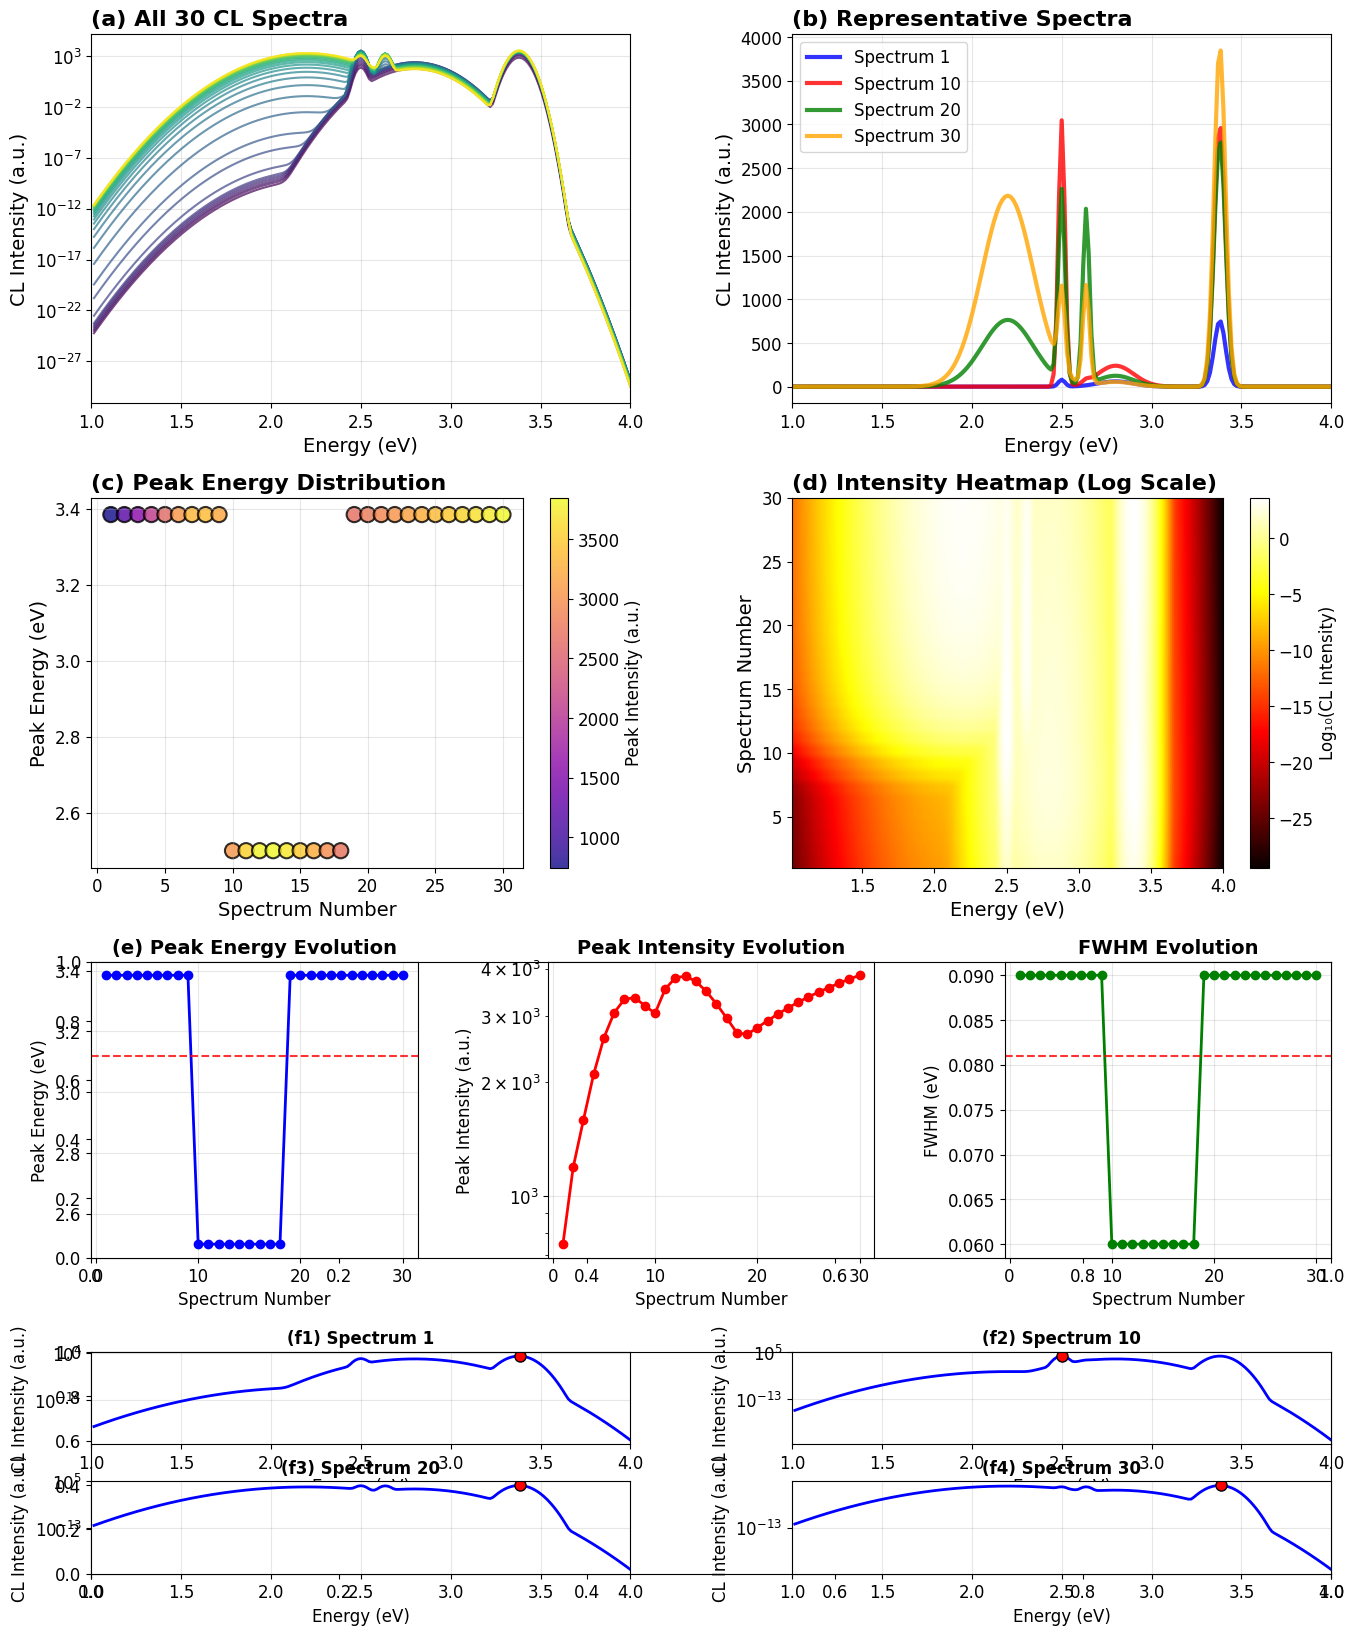

Publication Figure Created!
This comprehensive figure includes:
- (a) Complete spectral overview
- (b) Representative spectra comparison
- (c) Peak energy distribution
- (d) Intensity heatmap
- (e) Evolution analysis (3 panels)
- (f1-f4) Detailed individual spectra


In [35]:
# Create a publication-quality combined figure
fig = plt.figure(figsize=(16, 20))

# Create a custom layout with different sized subplots
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 0.8, 0.6], hspace=0.3, wspace=0.3)

# Top row: Overview plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Second row: Peak analysis and heatmap
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Third row: Evolution analysis (3 panels)
ax5 = fig.add_subplot(gs[2, :])

# Fourth row: Selected individual spectra
ax6 = fig.add_subplot(gs[3, :])

# Panel A: All spectra overview
colors = cm.viridis(np.linspace(0, 1, 30))
for i in range(30):
    ax1.semilogy(energy, spectra_data[:, i], color=colors[i], alpha=0.7, linewidth=1.5)
ax1.set_xlabel('Energy (eV)', fontsize=14)
ax1.set_ylabel('CL Intensity (a.u.)', fontsize=14)
ax1.set_title('(a) All 30 CL Spectra', fontsize=16, fontweight='bold', loc='left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1.0, 4.0)

# Panel B: Selected spectra
selected_indices = [0, 9, 19, 29]  # First, 10th, 20th, 30th
selected_colors = ['blue', 'red', 'green', 'orange']
for i, idx in enumerate(selected_indices):
    ax2.plot(energy, spectra_data[:, idx], color=selected_colors[i], 
             linewidth=3, label=f'Spectrum {idx+1}', alpha=0.8)
ax2.set_xlabel('Energy (eV)', fontsize=14)
ax2.set_ylabel('CL Intensity (a.u.)', fontsize=14)
ax2.set_title('(b) Representative Spectra', fontsize=16, fontweight='bold', loc='left')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1.0, 4.0)

# Panel C: Peak positions
scatter = ax3.scatter(spectrum_numbers, peak_energies, c=peak_intensities, 
                     cmap='plasma', s=120, alpha=0.8, edgecolors='black', linewidth=1.5)
ax3.set_xlabel('Spectrum Number', fontsize=14)
ax3.set_ylabel('Peak Energy (eV)', fontsize=14)
ax3.set_title('(c) Peak Energy Distribution', fontsize=16, fontweight='bold', loc='left')
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Peak Intensity (a.u.)', fontsize=12)

# Panel D: Heatmap
heatmap_data = spectra_data.T
heatmap_log = np.log10(heatmap_data + 1e-30)
im = ax4.imshow(heatmap_log, aspect='auto', cmap='hot', origin='lower',
                extent=[energy[0], energy[-1], 1, 30])
ax4.set_xlabel('Energy (eV)', fontsize=14)
ax4.set_ylabel('Spectrum Number', fontsize=14)
ax4.set_title('(d) Intensity Heatmap (Log Scale)', fontsize=16, fontweight='bold', loc='left')
cbar2 = plt.colorbar(im, ax=ax4)
cbar2.set_label('Log₁₀(CL Intensity)', fontsize=12)

# Panel E: Evolution analysis (horizontal layout)
# Create subplot within the evolution area
gs_evol = gs[2, :].subgridspec(1, 3, wspace=0.4)
ax5a = fig.add_subplot(gs_evol[0])
ax5b = fig.add_subplot(gs_evol[1])
ax5c = fig.add_subplot(gs_evol[2])

# Peak energy evolution
ax5a.plot(spectrum_numbers, peak_energies, 'bo-', linewidth=2, markersize=6)
ax5a.axhline(y=np.mean(peak_energies), color='red', linestyle='--', alpha=0.8)
ax5a.set_xlabel('Spectrum Number', fontsize=12)
ax5a.set_ylabel('Peak Energy (eV)', fontsize=12)
ax5a.set_title('(e) Peak Energy Evolution', fontsize=14, fontweight='bold')
ax5a.grid(True, alpha=0.3)

# Peak intensity evolution
ax5b.semilogy(spectrum_numbers, peak_intensities, 'ro-', linewidth=2, markersize=6)
ax5b.set_xlabel('Spectrum Number', fontsize=12)
ax5b.set_ylabel('Peak Intensity (a.u.)', fontsize=12)
ax5b.set_title('Peak Intensity Evolution', fontsize=14, fontweight='bold')
ax5b.grid(True, alpha=0.3)

# FWHM evolution
ax5c.plot(spectrum_numbers, fwhm_values, 'go-', linewidth=2, markersize=6)
ax5c.axhline(y=np.mean(fwhm_values), color='red', linestyle='--', alpha=0.8)
ax5c.set_xlabel('Spectrum Number', fontsize=12)
ax5c.set_ylabel('FWHM (eV)', fontsize=12)
ax5c.set_title('FWHM Evolution', fontsize=14, fontweight='bold')
ax5c.grid(True, alpha=0.3)

# Panel F: Selected individual spectra (2x2 grid)
gs_indiv = gs[3, :].subgridspec(2, 2, wspace=0.3, hspace=0.4)
selected_for_detail = [0, 9, 19, 29]  # Same as panel B
titles = ['Spectrum 1', 'Spectrum 10', 'Spectrum 20', 'Spectrum 30']

for idx, (spec_idx, title) in enumerate(zip(selected_for_detail, titles)):
    row, col = idx // 2, idx % 2
    ax_detail = fig.add_subplot(gs_indiv[row, col])
    
    ax_detail.semilogy(energy, spectra_data[:, spec_idx], 'b-', linewidth=2)
    peak_idx = np.argmax(spectra_data[:, spec_idx])
    peak_e = energy[peak_idx]
    peak_i = spectra_data[peak_idx, spec_idx]
    ax_detail.plot(peak_e, peak_i, 'ro', markersize=8, markeredgecolor='black')
    
    ax_detail.set_xlabel('Energy (eV)', fontsize=12)
    ax_detail.set_ylabel('CL Intensity (a.u.)', fontsize=12)
    ax_detail.set_title(f'(f{idx+1}) {title}', fontsize=12, fontweight='bold')
    ax_detail.grid(True, alpha=0.3)
    ax_detail.set_xlim(1.0, 4.0)

plt.savefig('CL_complete_publication_figure.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("Publication Figure Created!")
print("This comprehensive figure includes:")
print("- (a) Complete spectral overview")
print("- (b) Representative spectra comparison") 
print("- (c) Peak energy distribution")
print("- (d) Intensity heatmap")
print("- (e) Evolution analysis (3 panels)")
print("- (f1-f4) Detailed individual spectra")